#### Name: Venkatappareddy Manukonda

#### Course: MSCS-634 Advanced Big Data and Data Mining

#### Assignment: Regression Analysis with Regularization Techniques

The Diabetes dataset provides an opportunity to compare several regression techniques using the same set of clinical measurements. Rather than assuming that a more complex model automatically produces better predictions, this analysis examines how model complexity, feature selection, and regularization influence predictive performance. The workflow begins with a simple baseline model and gradually introduces additional predictors, nonlinear transformations, and regularization to understand how each decision changes the model's ability to generalize to unseen data.

# Step 1: Data Preparation and Exploration

Every modeling decision depends on the quality of the underlying data. Before fitting any regression model, I first examined the dataset to understand its structure, verify that no quality issues were present, and identify the relationships between the available features and the target variable. Performing these checks early makes it easier to interpret differences between models later in the analysis because any performance changes can be attributed to the modeling approach rather than inconsistencies in the data.

## Import Libraries

The analysis relies on a small set of well-established Python libraries. Pandas is used for data manipulation, Matplotlib for visualization, and Scikit-learn for loading the dataset, building regression models, and evaluating their performance.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
np.random.seed(42)

## Load the Dataset

The Diabetes dataset contains standardized clinical measurements collected from diabetes patients together with a continuous target variable representing disease progression. Since the goal is to compare several regression techniques rather than perform extensive data cleaning, the first step is simply to organize the dataset into a DataFrame and inspect its contents.

In [9]:
# Load the Diabetes dataset
diabetes = load_diabetes()

# Create a DataFrame
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

# Add the target variable
df["target"] = diabetes.target

# Display the first five rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,135.0


## Explore the Dataset

Before building predictive models, I checked the overall structure of the dataset, including its dimensions, data types, missing values, duplicate records, and descriptive statistics. Although the dataset is distributed as a cleaned benchmark dataset, confirming these characteristics provides confidence that the comparison between regression models is based on reliable data.

In [10]:
print(f"Dataset Shape: {df.shape}")

print("\nFeature Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

Dataset Shape: (442, 11)

Feature Names
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Data Types
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Missing Values
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Duplicate Records
0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-3.634285e-16,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.308343e-16,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-8.045349e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,1.281655e-16,0.047619,-0.112400,-0.036656,-0.005671,0.035644,0.132044
s1,442.0,-8.835316e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,1.327024e-16,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-4.574646e-16,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,3.777301e-16,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,-3.830854e-16,0.047619,-0.126097,-0.033249,-0.001948,0.032433,0.133599
s6,442.0,-3.412882e-16,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### Observation

The dataset contains 442 observations, 10 predictor variables, and one continuous target variable. No missing values or duplicate records were identified, so additional cleaning was unnecessary. The predictor variables are already standardized, allowing the later comparison between regression models to focus on differences in modeling behavior rather than differences introduced during preprocessing.

## Explore the Target Variable

Before training the models, I examined the distribution of the target variable to understand how disease progression varies across the dataset. A wider distribution generally represents a more challenging prediction problem because the model must explain a broader range of outcomes instead of values concentrated around a single average.

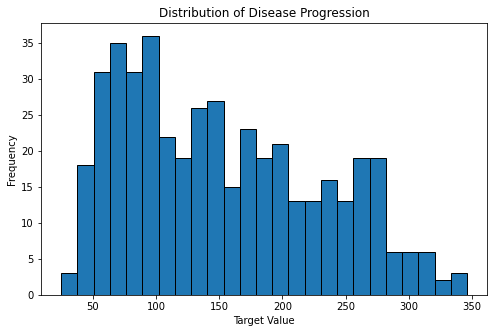

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    df["target"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Disease Progression")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.show()

### Observation

The target values are distributed across a relatively broad range, indicating that disease progression differs considerably among patients. This variation suggests that no single predictor is likely to explain the target completely, making it important to evaluate both simple and more complex regression models throughout the analysis.

## Examine Feature Relationships

Since the first regression model uses only one predictor, I explored how each feature relates to the target before selecting that variable. This provides a practical reason for choosing the baseline feature instead of selecting it arbitrarily.

In [14]:
# Calculate correlation with the target variable
correlation = df.corr()["target"].sort_values(ascending=False)

correlation

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441484
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

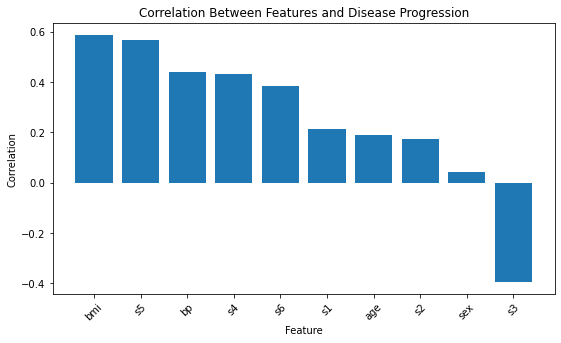

In [15]:
feature_corr = correlation.drop("target")

plt.figure(figsize=(9,5))

plt.bar(
    feature_corr.index,
    feature_corr.values
)

plt.title("Correlation Between Features and Disease Progression")
plt.xlabel("Feature")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

### Observation

Several variables show meaningful relationships with the target, but none dominates the prediction problem by itself. BMI exhibits one of the strongest positive correlations, making it an appropriate choice for establishing the initial baseline model. At the same time, the distribution of the remaining correlations suggests that combining multiple clinical measurements should provide additional predictive information beyond what BMI alone can capture.

## Prepare the Data for Modeling

To compare the regression models fairly, the dataset is divided into training and testing subsets. The models learn patterns using only the training data, while the testing data remains untouched until evaluation. This separation provides a better indication of how well each model is likely to perform on new observations rather than measuring how well it reproduces data it has already seen.

In [16]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (353, 10)
Testing Shape : (89, 10)


In [17]:
def evaluate_model(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "MSE": [mse],
        "RMSE": [np.sqrt(mse)],
        "R²": [r2_score(y_true, y_pred)]
    })

# Step 2: Simple Linear Regression

The first model uses only one predictor, BMI, to estimate disease progression. Starting with a single-feature model is useful because it creates a simple baseline. If the later models improve only slightly, then their added complexity may not be worth much. If they improve clearly, then it suggests that the additional clinical measurements are contributing useful information.

## Build the Model

BMI was selected because it showed one of the stronger positive relationships with the target variable during the correlation check. This does not mean BMI fully explains disease progression, but it makes the feature a reasonable choice for a baseline model.

In [18]:
# Use BMI as the single predictor
X_simple = df[["bmi"]]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_simple,
    y_train_simple
)

simple_predictions = simple_model.predict(
    X_test_simple
)

In [19]:
simple_results = evaluate_model(
    "Simple Linear Regression",
    y_test_simple,
    simple_predictions
)

simple_results

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,52.259976,4061.825928,63.732456,0.23335


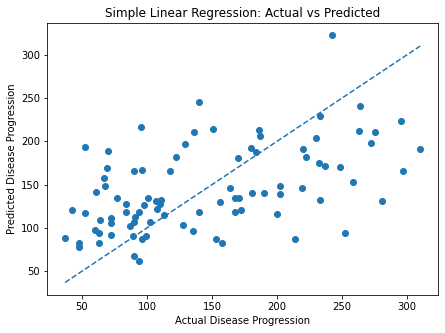

In [20]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_simple,
    simple_predictions
)

plt.plot(
    [y_test_simple.min(), y_test_simple.max()],
    [y_test_simple.min(), y_test_simple.max()],
    linestyle="--"
)

plt.title("Simple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")

plt.show()

## Interpretation

The simple regression model captures the general direction of the relationship, but the predictions are still widely spread around the reference line. This is expected because BMI is only one part of the patient profile. The model is useful as a baseline, but the amount of spread suggests that disease progression cannot be explained well by BMI alone.

In [21]:
# Store model results for final comparison
results_list = [simple_results]

# Step 3: Multiple Linear Regression

The next model uses all available predictor variables instead of relying only on BMI. This tests whether combining several clinical measurements improves prediction enough to justify the added complexity. In a medical dataset, this is usually a more realistic setup because disease progression is unlikely to depend on one measurement alone.

## Build and Evaluate the Model

The same training and testing split created earlier is used here. Keeping the split consistent makes the comparison with the simple regression model fair.

In [22]:
multiple_model = LinearRegression()

multiple_model.fit(
    X_train,
    y_train
)

multiple_predictions = multiple_model.predict(
    X_test
)

multiple_results = evaluate_model(
    "Multiple Linear Regression",
    y_test,
    multiple_predictions
)

multiple_results

,Model,MAE,MSE,RMSE,R²
0,Multiple Linear Regression,42.793893,2900.173288,53.853257,0.452607


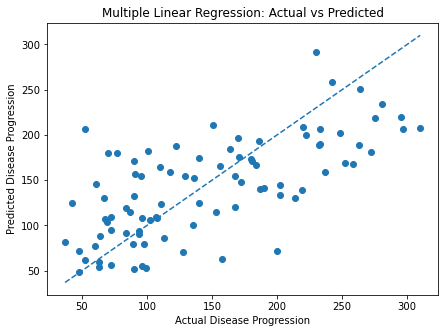

In [23]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    multiple_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")

plt.show()

In [24]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficient_table

,Feature,Coefficient
4,s1,-931.461261
8,s5,736.189098
2,bmi,542.425753
5,s2,518.044055
3,bp,347.708305
7,s4,275.310038
1,sex,-241.966248
6,s3,163.403535
9,s6,48.671125
0,age,37.900314


## Interpretation

The multiple regression model uses more information than the simple model, so it has a better chance of capturing the variation in disease progression. The actual-versus-predicted plot should appear more aligned with the reference line than the BMI-only model, although some spread is still expected. The coefficient table also helps show which features had stronger influence in the fitted linear model.

The important point is that the model is not just more complex for the sake of being complex. It is using additional clinical measurements that may explain parts of the target that BMI alone could not capture.

In [25]:
results_list.append(multiple_results)

# Step 4: Polynomial Regression

The previous models assume that the relationship between the predictors and the target is linear. Polynomial Regression relaxes that assumption by creating additional nonlinear features. While this added flexibility may improve the fit, it also increases the possibility of overfitting. Instead of assuming that a higher polynomial degree is always better, I compared several degrees to observe how increasing complexity influences model performance on both the training and testing data.

## Compare Different Polynomial Degrees

To understand how model complexity changes performance, I evaluated polynomial models with degrees 1, 2, and 3. Degree 1 is equivalent to ordinary linear regression and serves as a useful reference point. Higher degrees introduce more flexibility, making it possible to capture nonlinear relationships, but they also increase the risk that the model begins fitting noise rather than meaningful patterns.

In [26]:
polynomial_results = []

for degree in [1, 2, 3]:

    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])

    poly_model.fit(X_train, y_train)

    train_predictions = poly_model.predict(X_train)
    test_predictions = poly_model.predict(X_test)

    train_r2 = r2_score(y_train, train_predictions)
    test_metrics = evaluate_model(
        f"Polynomial Regression (Degree {degree})",
        y_test,
        test_predictions
    )

    test_metrics["Training R²"] = train_r2

    polynomial_results.append(test_metrics)

poly_df = pd.concat(polynomial_results, ignore_index=True)

poly_df

,Model,MAE,MSE,RMSE,R²,Training R²
0,Polynomial Regression (Degree 1),42.793893,2900.173288,53.853257,0.452607,0.527920
1,Polynomial Regression (Degree 2),43.577726,3095.775086,55.639690,0.415688,0.606156
2,Polynomial Regression (Degree 3),169.605070,97520.886551,312.283343,-17.406586,0.877336


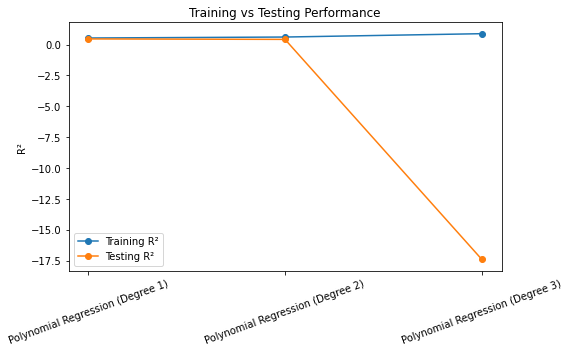

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    poly_df["Model"],
    poly_df["Training R²"],
    marker="o",
    label="Training R²"
)

plt.plot(
    poly_df["Model"],
    poly_df["R²"],
    marker="o",
    label="Testing R²"
)

plt.xticks(rotation=20)

plt.ylabel("R²")

plt.title("Training vs Testing Performance")

plt.legend()

plt.tight_layout()

plt.show()

## Interpretation

The comparison shows how increasing the polynomial degree changes the balance between flexibility and generalization. As expected, the training score tends to improve as the model becomes more flexible because it can represent increasingly complex relationships.

The testing score, however, is more informative. If the testing performance improves alongside the training performance, the additional complexity is helping the model capture meaningful structure in the data. If the training score continues to increase while the testing score remains unchanged or begins to decline, the model is likely fitting patterns that do not generalize beyond the training data.

Rather than selecting the highest polynomial degree automatically, the comparison highlights the importance of balancing model complexity with the ability to perform well on unseen observations.

In [28]:
results_list.append(
    poly_df.loc[
        poly_df["R²"].idxmax()
    ].to_frame().T
)

# Step 5: Ridge and Lasso Regression

The earlier models focused on increasing model complexity, but another way to improve a regression model is to control that complexity. Ridge and Lasso introduce regularization by placing constraints on the regression coefficients. The purpose is not simply to reduce coefficient values, but to improve how well the model generalizes when making predictions on unseen data.

Rather than choosing a single regularization strength, I evaluated several alpha values to observe how changing the amount of regularization influences prediction performance.

## Ridge Regression

Ridge Regression applies L2 regularization, which reduces the magnitude of the regression coefficients without removing predictors from the model. This approach is useful when several variables contribute information and the goal is to stabilize the model rather than simplify it.

In [29]:
ridge_results = []

alpha_values = [0.01, 0.1, 1, 10]

for alpha in alpha_values:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(X_train, y_train)

    ridge_predictions = ridge_model.predict(X_test)

    ridge_metrics = evaluate_model(
        f"Ridge (α={alpha})",
        y_test,
        ridge_predictions
    )

    ridge_metrics["Alpha"] = alpha

    ridge_results.append(ridge_metrics)

ridge_df = pd.concat(ridge_results, ignore_index=True)

ridge_df

,Model,MAE,MSE,RMSE,R²,Alpha
0,Ridge (α=0.01),42.836839,2882.278969,53.686860,0.455984,0.01
1,Ridge (α=0.1),42.996907,2856.481732,53.446064,0.460853,0.10
2,Ridge (α=1),46.138820,3077.414278,55.474447,0.419153,1.00
3,Ridge (α=10),58.030753,4443.951638,66.662971,0.161226,10.00


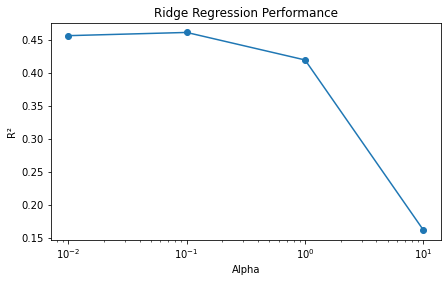

In [30]:
plt.figure(figsize=(7,4))

plt.plot(
    ridge_df["Alpha"],
    ridge_df["R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("R²")

plt.title("Ridge Regression Performance")

plt.show()

## Interpretation

The results show that the amount of regularization influences model performance. When alpha is very small, Ridge behaves similarly to ordinary linear regression because the penalty is weak. As alpha increases, the coefficients become more constrained, which may improve stability but can also reduce predictive performance if the model becomes too restricted.

The best alpha is therefore not necessarily the smallest or the largest value. It is the value that provides the best balance between flexibility and generalization.

In [31]:
best_ridge = ridge_df.loc[
    ridge_df["R²"].idxmax()
].to_frame().T

results_list.append(best_ridge)

## Lasso Regression

Lasso Regression applies L1 regularization. Unlike Ridge, Lasso is capable of shrinking some regression coefficients to exactly zero. This effectively removes less influential predictors from the model and can produce a simpler model without requiring manual feature selection.

In [32]:
lasso_results = []

for alpha in alpha_values:

    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso_model.fit(
        X_train,
        y_train
    )

    lasso_predictions = lasso_model.predict(
        X_test
    )

    metrics = evaluate_model(
        f"Lasso (α={alpha})",
        y_test,
        lasso_predictions
    )

    metrics["Alpha"] = alpha
    metrics["Non-Zero Coefficients"] = np.sum(
        lasso_model.coef_ != 0
    )

    lasso_results.append(metrics)

lasso_df = pd.concat(
    lasso_results,
    ignore_index=True
)

lasso_df

,Model,MAE,MSE,RMSE,R²,Alpha,Non-Zero Coefficients
0,Lasso (α=0.01),42.831790,2878.546816,53.652091,0.456688,0.01,10
1,Lasso (α=0.1),42.854401,2798.190969,52.897930,0.471855,0.10,7
2,Lasso (α=1),49.730233,3403.570192,58.340125,0.357593,1.00,3
3,Lasso (α=10),64.006461,5361.533457,73.222493,-0.011963,10.00,0


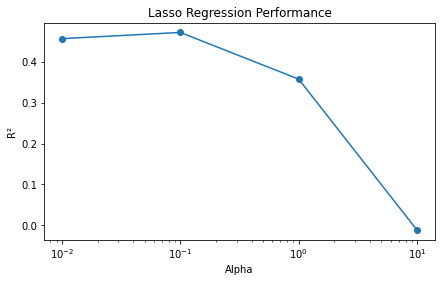

In [33]:
plt.figure(figsize=(7,4))

plt.plot(
    lasso_df["Alpha"],
    lasso_df["R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("R²")

plt.title("Lasso Regression Performance")

plt.show()

## Interpretation

Lasso responds differently to stronger regularization because increasing alpha can remove predictors from the model altogether. This reduction in model complexity may improve generalization when unnecessary predictors are present, but excessive regularization can also remove useful information and reduce predictive accuracy.

Comparing several alpha values makes it easier to identify the point where regularization helps the model without becoming overly restrictive.

In [35]:
best_lasso = lasso_df.loc[
    lasso_df["R²"].idxmax()
].to_frame().T

results_list.append(best_lasso)

# Step 6: Model Comparison and Analysis

Looking at each model individually is useful, but the broader objective is to understand how the modeling choices influenced prediction performance. Bringing the results together makes it easier to identify which approach achieved the best balance between accuracy, model complexity, and generalization.

In [36]:
# Combine all model results
final_results = pd.concat(results_list, ignore_index=True)

# Display comparison table
final_results

,Model,MAE,MSE,RMSE,R²,Training R²,Alpha,Non-Zero Coefficients
0,Simple Linear Regression,52.26,4061.83,63.7325,0.23335,NaN,NaN,NaN
1,Multiple Linear Regression,42.7939,2900.17,53.8533,0.452607,NaN,NaN,NaN
2,Polynomial Regression (Degree 1),42.7939,2900.17,53.8533,0.452607,0.52792,NaN,NaN
3,Ridge (α=0.1),42.9969,2856.48,53.4461,0.460853,NaN,0.1,NaN
4,Lasso (α=0.1),42.8544,2798.19,52.8979,0.471855,NaN,0.1,7


## Compare Model Performance

The comparison table summarizes the performance of the baseline model, the multiple regression model, the strongest polynomial model, and the best-performing Ridge and Lasso models. Evaluating the models side by side makes it easier to understand how each modeling decision influenced the prediction results.

In [37]:
comparison = final_results.sort_values(
    by="R²",
    ascending=False
)

comparison

,Model,MAE,MSE,RMSE,R²,Training R²,Alpha,Non-Zero Coefficients
4,Lasso (α=0.1),42.8544,2798.19,52.8979,0.471855,NaN,0.1,7
3,Ridge (α=0.1),42.9969,2856.48,53.4461,0.460853,NaN,0.1,NaN
1,Multiple Linear Regression,42.7939,2900.17,53.8533,0.452607,NaN,NaN,NaN
2,Polynomial Regression (Degree 1),42.7939,2900.17,53.8533,0.452607,0.52792,NaN,NaN
0,Simple Linear Regression,52.26,4061.83,63.7325,0.23335,NaN,NaN,NaN


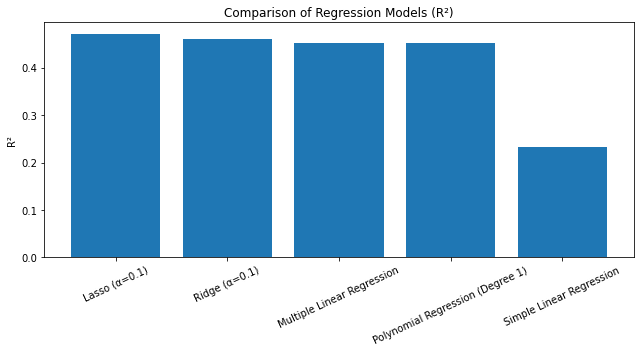

In [38]:
plt.figure(figsize=(9,5))

plt.bar(
    comparison["Model"],
    comparison["R²"]
)

plt.ylabel("R²")
plt.title("Comparison of Regression Models (R²)")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

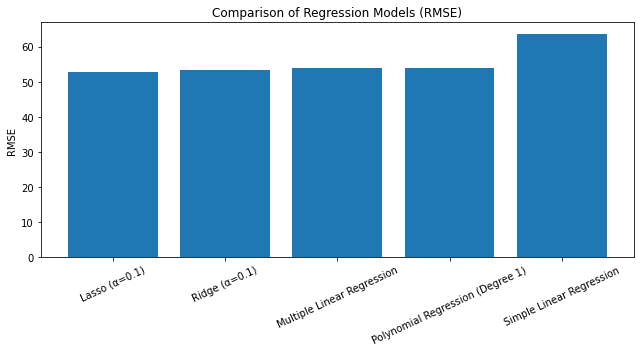

In [39]:
plt.figure(figsize=(9,5))

rmse_comparison = final_results.sort_values(
    by="RMSE"
)

plt.bar(
    rmse_comparison["Model"],
    rmse_comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Comparison of Regression Models (RMSE)")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

## Discussion

Looking across all of the models made it easier to understand how each design choice affected the predictions. The simple linear regression model established a useful starting point by showing that BMI has a meaningful relationship with disease progression. At the same time, its performance made it clear that one predictor cannot represent the full complexity of the dataset.

Using all available features improved the model because additional clinical measurements contributed information that BMI alone could not provide. Polynomial Regression introduced more flexibility by allowing nonlinear relationships, but the comparison between the training and testing results showed why model complexity should be increased carefully. A more flexible model can fit the training data very well, yet still perform poorly on new observations if it begins capturing noise instead of meaningful patterns.

Ridge and Lasso addressed the same problem from a different direction. Rather than adding complexity, they controlled it through regularization. Ridge reduced the influence of large coefficients while keeping every predictor in the model, whereas Lasso simplified the model by shrinking less informative coefficients toward zero. Comparing different alpha values demonstrated that regularization is most effective when it balances predictive performance with model stability instead of simply making the model more restrictive.

# Conclusion

This analysis showed that regression modeling is a balance between predictive performance and model complexity rather than a search for the most sophisticated algorithm. Each technique approached the prediction problem differently, and comparing them side by side made those differences easier to understand.

The simple regression model provided a useful baseline, multiple regression demonstrated the value of incorporating additional predictors, polynomial regression illustrated how increasing flexibility can introduce overfitting, and Ridge and Lasso showed how regularization can improve generalization by controlling model complexity. Together, these models provided a broader understanding of how different regression strategies behave when applied to the same dataset.

Although no single model predicted disease progression perfectly, the comparison demonstrated that selecting an appropriate model requires considering prediction accuracy, generalization, and interpretability together rather than focusing on a single evaluation metric.